In [1]:
# Librerias
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers, optimizers, metrics
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing import image



from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


In [2]:
# Directorios
train_dir = "../data/lesions/train"
test_dir = "../data/lesions/test" 

In [3]:
SEED = 42
tf.random.set_seed(SEED)

In [4]:
color_train = "#5FAA3F"  # azul
color_val = "#984bb7" 

# Importar y Redimensionar Máscaras

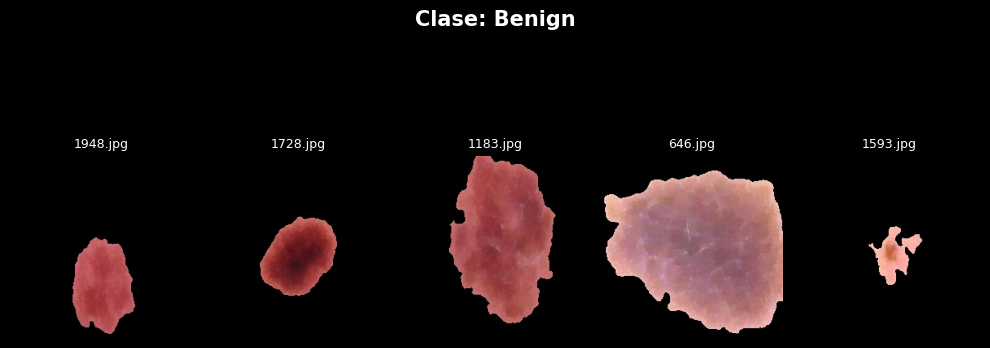

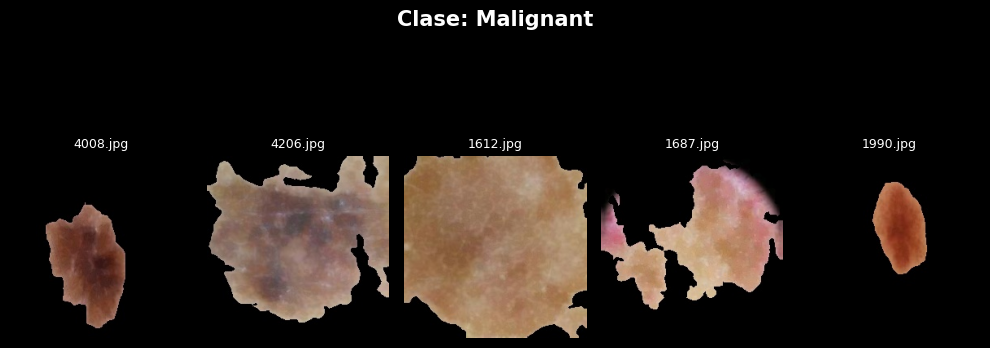

In [5]:
def mostrar_imagenes_random(carpeta, clase=None, n=5):
    if clase:
        carpeta = os.path.join(carpeta, clase)

    archivos = random.sample(os.listdir(carpeta), n)

    fig, axes = plt.subplots(1, n, figsize=(10, 4), facecolor='black')
    fig.suptitle(f"Clase: {clase}", fontsize=15, fontweight='bold', y=1.05, color='white')

    for ax, img_name in zip(axes, archivos):
        img = cv2.imread(os.path.join(carpeta, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(img_name, fontsize=9, color='white')
        ax.axis('off')
        ax.set_facecolor('black')  # fondo negro también para los ejes

    plt.subplots_adjust(top=0.8, wspace=0.05)  # red
    plt.tight_layout()
    plt.show()


# Ejemplo de uso
mostrar_imagenes_random(train_dir, "Benign", 5)
mostrar_imagenes_random(train_dir, "Malignant", 5)

### Normalización y Reescalado 

In [6]:
ROWS, COLS = 224, 224
BATCH= 32

In [7]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

In [8]:
train_gen = train_datagen.flow_from_directory(
    directory=train_dir,
    class_mode='categorical',      # 2 clases: Benign / Malignant
    batch_size=BATCH,
    target_size=(ROWS, COLS),
    color_mode='rgb',
    shuffle=True,
    seed=SEED
)

test_gen = test_datagen.flow_from_directory(
    directory=test_dir,
    class_mode='categorical',
    batch_size=BATCH,
    target_size=(ROWS, COLS),
    color_mode='rgb',
    shuffle=False,
    seed=SEED
)

Found 11879 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


# Modelo

In [ ]:
ROWS, COLS = 224, 224
input_shape = (ROWS, COLS, 3)

# --- Definición funcional idéntica ---
inputs = layers.Input(shape=input_shape)

# Bloque 1
x = layers.Conv2D(32, (3,3), activation='relu', padding='same', name="conv1")(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)

# Bloque 2
x = layers.Conv2D(64, (3,3), activation='relu', padding='same', name="conv2")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.25)(x)

# Bloque 3
x = layers.Conv2D(128, (3,3), activation='relu', padding='same', name="conv3")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.3)(x)

# Clasificación
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4), name="dense1")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(2, activation='softmax', name="output")(x)

2025-10-15 17:55:09.771748: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-10-15 17:55:09.771785: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-10-15 17:55:09.771794: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-10-15 17:55:09.771812: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-10-15 17:55:09.771823: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [10]:
modelo1 = tf.keras.Model(inputs=inputs, outputs=outputs, name="MelanomaNet")

In [11]:
modelo1.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall')
    ]
)

In [12]:
history_1= modelo1.fit(
    train_gen,
    validation_data=test_gen,
    epochs=30
)

Epoch 1/30


/Users/martinagarciagonzalez/Library/Python/3.12/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2025-10-15 17:55:10.693935: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


372/372 ━━━━━━━━━━━━━━━━━━━━ 122s 321ms/step - accuracy: 0.7170 - loss: 0.8799 - precision: 0.7170 - recall: 0.7170 - val_accuracy: 0.5000 - val_loss: 1.3347 - val_precision: 0.5000 - val_recall: 0.5000
Epoch 2/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 198s 533ms/step - accuracy: 0.7765 - loss: 0.5718 - precision: 0.7765 - recall: 0.7765 - val_accuracy: 0.8165 - val_loss: 0.4598 - val_precision: 0.8165 - val_recall: 0.8165
Epoch 3/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 215s 577ms/step - accuracy: 0.7903 - loss: 0.5491 - precision: 0.7903 - recall: 0.7903 - val_accuracy: 0.7700 - val_loss: 0.5026 - val_precision: 0.7700 - val_recall: 0.7700
Epoch 4/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 212s 570ms/step - accuracy: 0.7934 - loss: 0.5378 - precision: 0.7934 - recall: 0.7934 - val_accuracy: 0.8370 - val_loss: 0.4528 - val_precision: 0.8370 - val_recall: 0.8370
Epoch 5/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 155s 417ms/step - accuracy: 0.8075 - loss: 0.5002 - precision: 0.8075 - recall: 0.8075 - val_accuracy: 0.8275 - val

# Evaluación Modelo

## Curvas Train Vs Val

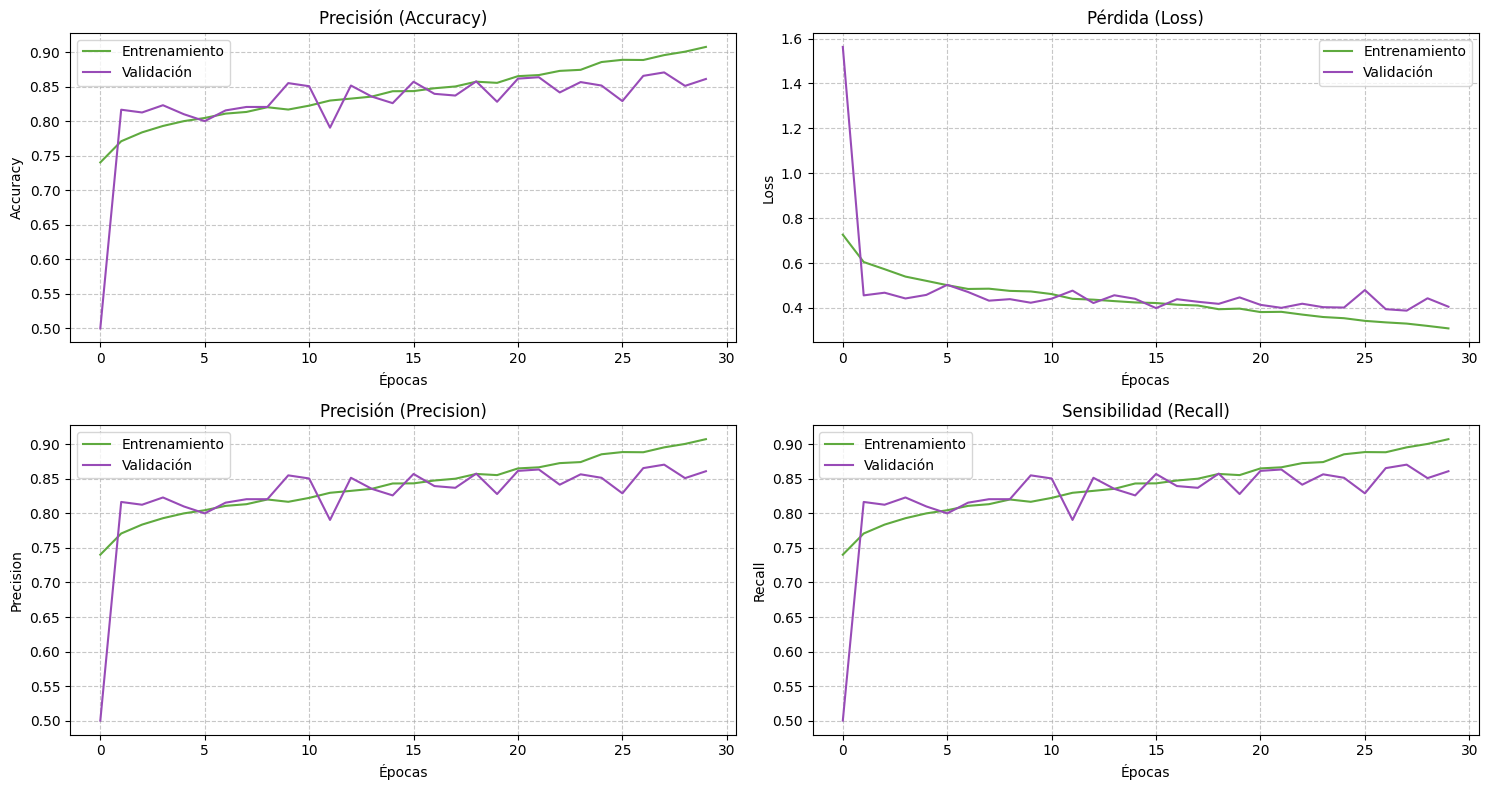

In [75]:
plt.figure(figsize=(15, 8))

# Accuracy
plt.subplot(2, 2, 1)
plt.plot(history_1.history['accuracy'], color=color_train, label='Entrenamiento')
plt.plot(history_1.history['val_accuracy'], color=color_val, label='Validación')
plt.title('Precisión (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Loss
plt.subplot(2, 2, 2)
plt.plot(history_1.history['loss'], color=color_train, label='Entrenamiento')
plt.plot(history_1.history['val_loss'], color=color_val, label='Validación')
plt.title('Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Precision (si definiste precision en metrics del modelo)
plt.subplot(2, 2, 3)
plt.plot(history_1.history['precision'], color=color_train, label='Entrenamiento')
plt.plot(history_1.history['val_precision'], color=color_val, label='Validación')
plt.title('Precisión (Precision)')
plt.xlabel('Épocas')
plt.ylabel('Precision')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Recall (si definiste recall en metrics del modelo)
plt.subplot(2, 2, 4)
plt.plot(history_1.history['recall'], color=color_train, label='Entrenamiento')
plt.plot(history_1.history['val_recall'], color=color_val, label='Validación')
plt.title('Sensibilidad (Recall)')
plt.xlabel('Épocas')
plt.ylabel('Recall')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Matriz de Confusión

In [74]:
y_pred_prob = modelo1.predict(test_gen)
y_true = test_gen.classes

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step


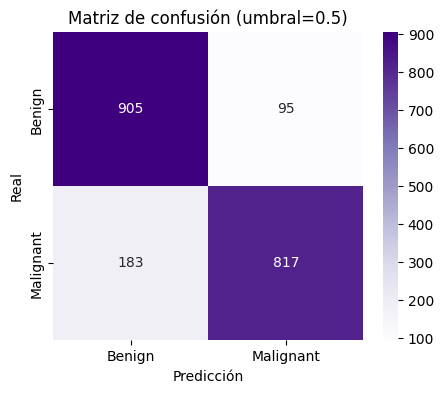

In [66]:
umbral = 0.5
y_pred_class = (y_pred_prob[:, 1] >= umbral).astype(int)

cm = confusion_matrix(y_true, y_pred_class)

labels = list(test_gen.class_indices.keys())
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title(f"Matriz de confusión (umbral={umbral})")
plt.show()

In [67]:
labels = list(test_gen.class_indices.keys())
print("Orden de clases:", test_gen.class_indices)

# Generar el reporte automático
print(classification_report(y_true, y_pred_class, target_names=labels, digits=3))

Orden de clases: {'Benign': 0, 'Malignant': 1}
              precision    recall  f1-score   support

      Benign      0.832     0.905     0.867      1000
   Malignant      0.896     0.817     0.855      1000

    accuracy                          0.861      2000
   macro avg      0.864     0.861     0.861      2000
weighted avg      0.864     0.861     0.861      2000



## Imágenes Externas

In [80]:
external_dir = "../data/lesions/external"
ROWS, COLS = 224, 224
BATCH = 1  # una imagen por lote para visualizar fácilmente

ext_datagen = ImageDataGenerator(rescale=1./255)

ext_gen = ext_datagen.flow_from_directory(
    directory=external_dir,
    target_size=(ROWS, COLS),
    batch_size=BATCH,
    class_mode='categorical',
    shuffle=False
)

Found 45 images belonging to 2 classes.


In [81]:
# Probabilidades y clases
pred_probs = modelo1.predict(ext_gen)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = ext_gen.classes
labels = list(ext_gen.class_indices.keys())

/Users/martinagarciagonzalez/GitHub/skin-cancer-classifier/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


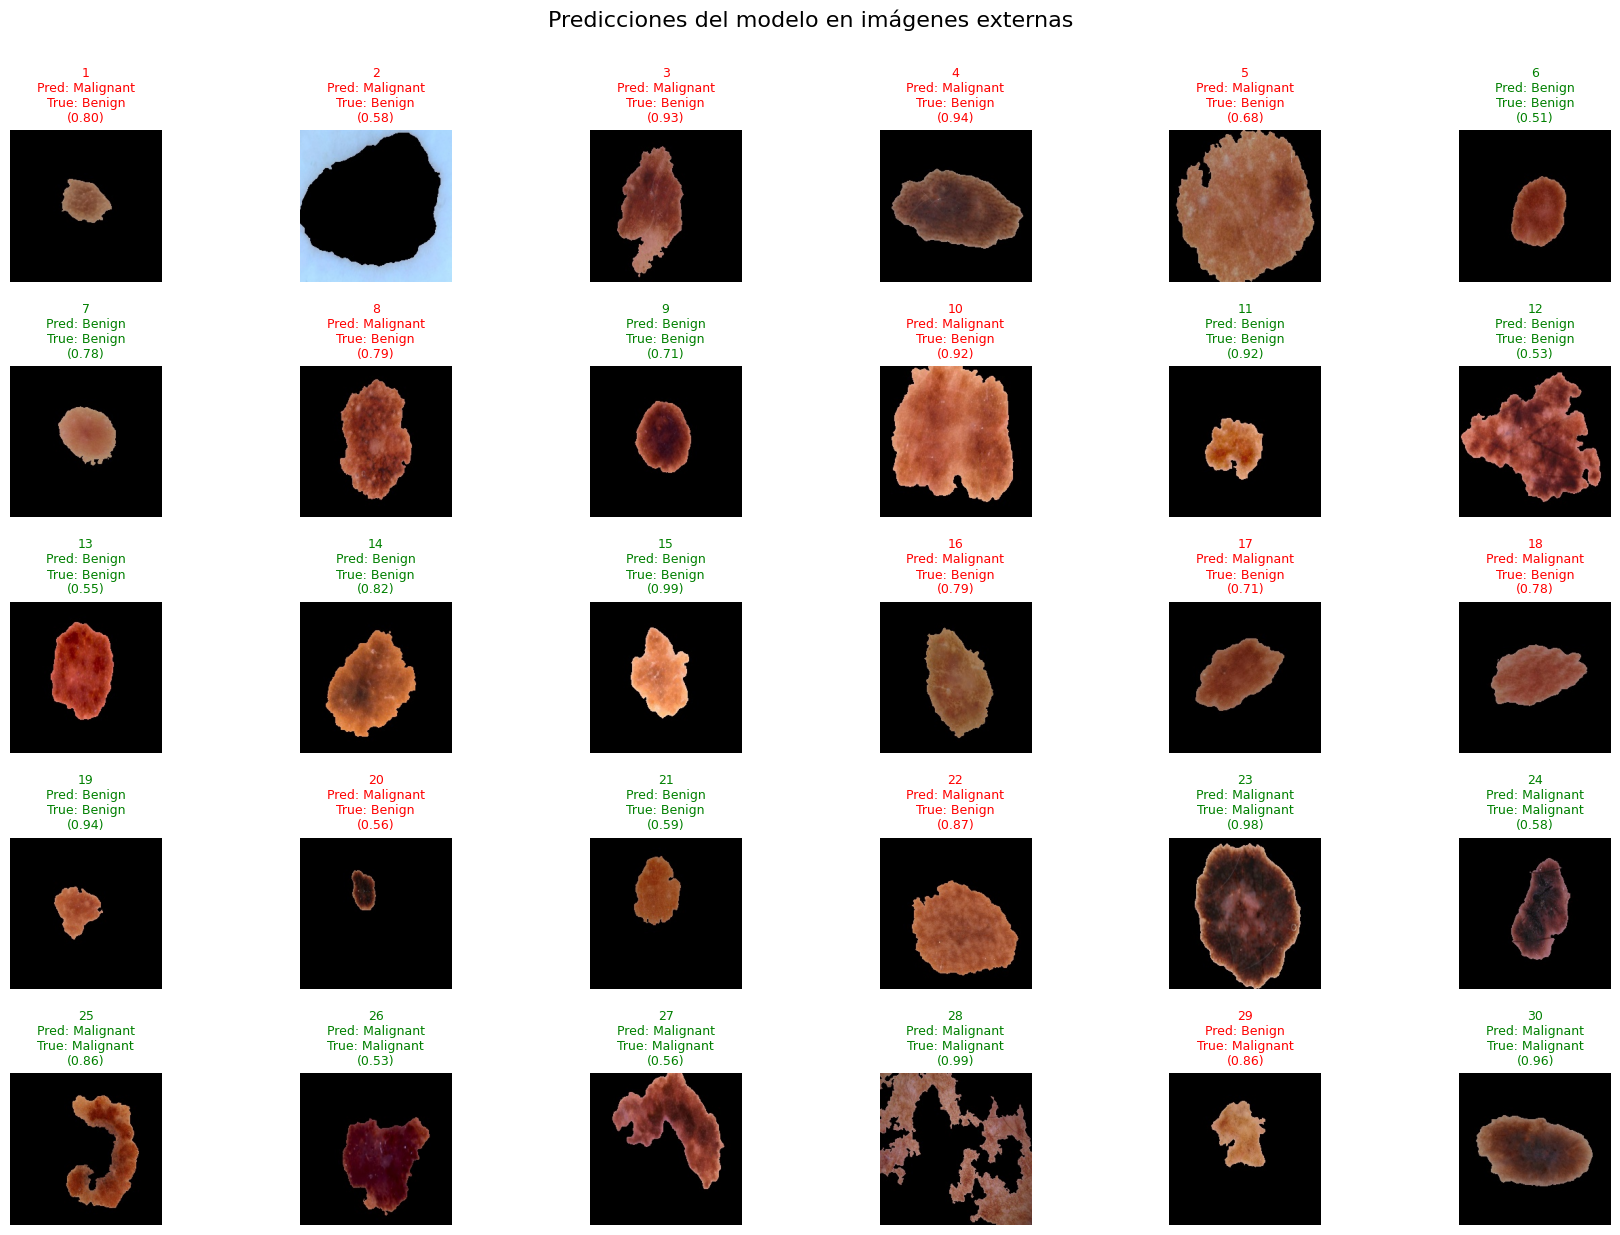

In [82]:
N = 30  # o len(ext_gen.filenames) si quieres todas
rows, cols = 5, 6

plt.figure(figsize=(18, 12))

for i in range(N):
    img, _ = ext_gen[i]
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img[0])

    true_label = labels[true_classes[i]]
    pred_label = labels[pred_classes[i]]
    prob = pred_probs[i][pred_classes[i]]

    color = "green" if true_label == pred_label else "red"
    plt.title(f"{i+1}\nPred: {pred_label}\nTrue: {true_label}\n({prob:.2f})", color=color, fontsize=9)
    plt.axis('off')

plt.tight_layout(pad=1.5)
plt.suptitle("Predicciones del modelo en imágenes externas", fontsize=16, y=1.03)
plt.show()

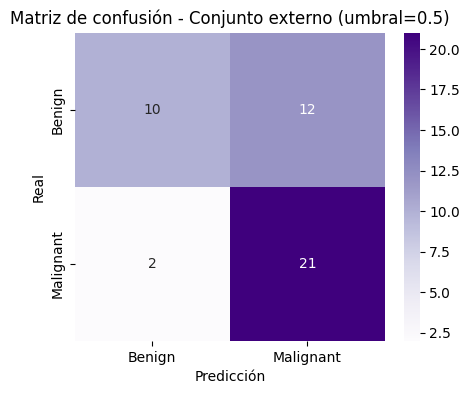

In [83]:
umbral = 0.5
y_pred_ext = (pred_probs[:, 1] >= umbral).astype(int)
y_true_ext = true_classes

# Calcular matriz de confusión
cm_ext = confusion_matrix(y_true_ext, y_pred_ext)

# Mostrar con seaborn
plt.figure(figsize=(5,4))
sns.heatmap(cm_ext, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title(f"Matriz de confusión - Conjunto externo (umbral={umbral})")
plt.show()

### Grad Cam

In [84]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

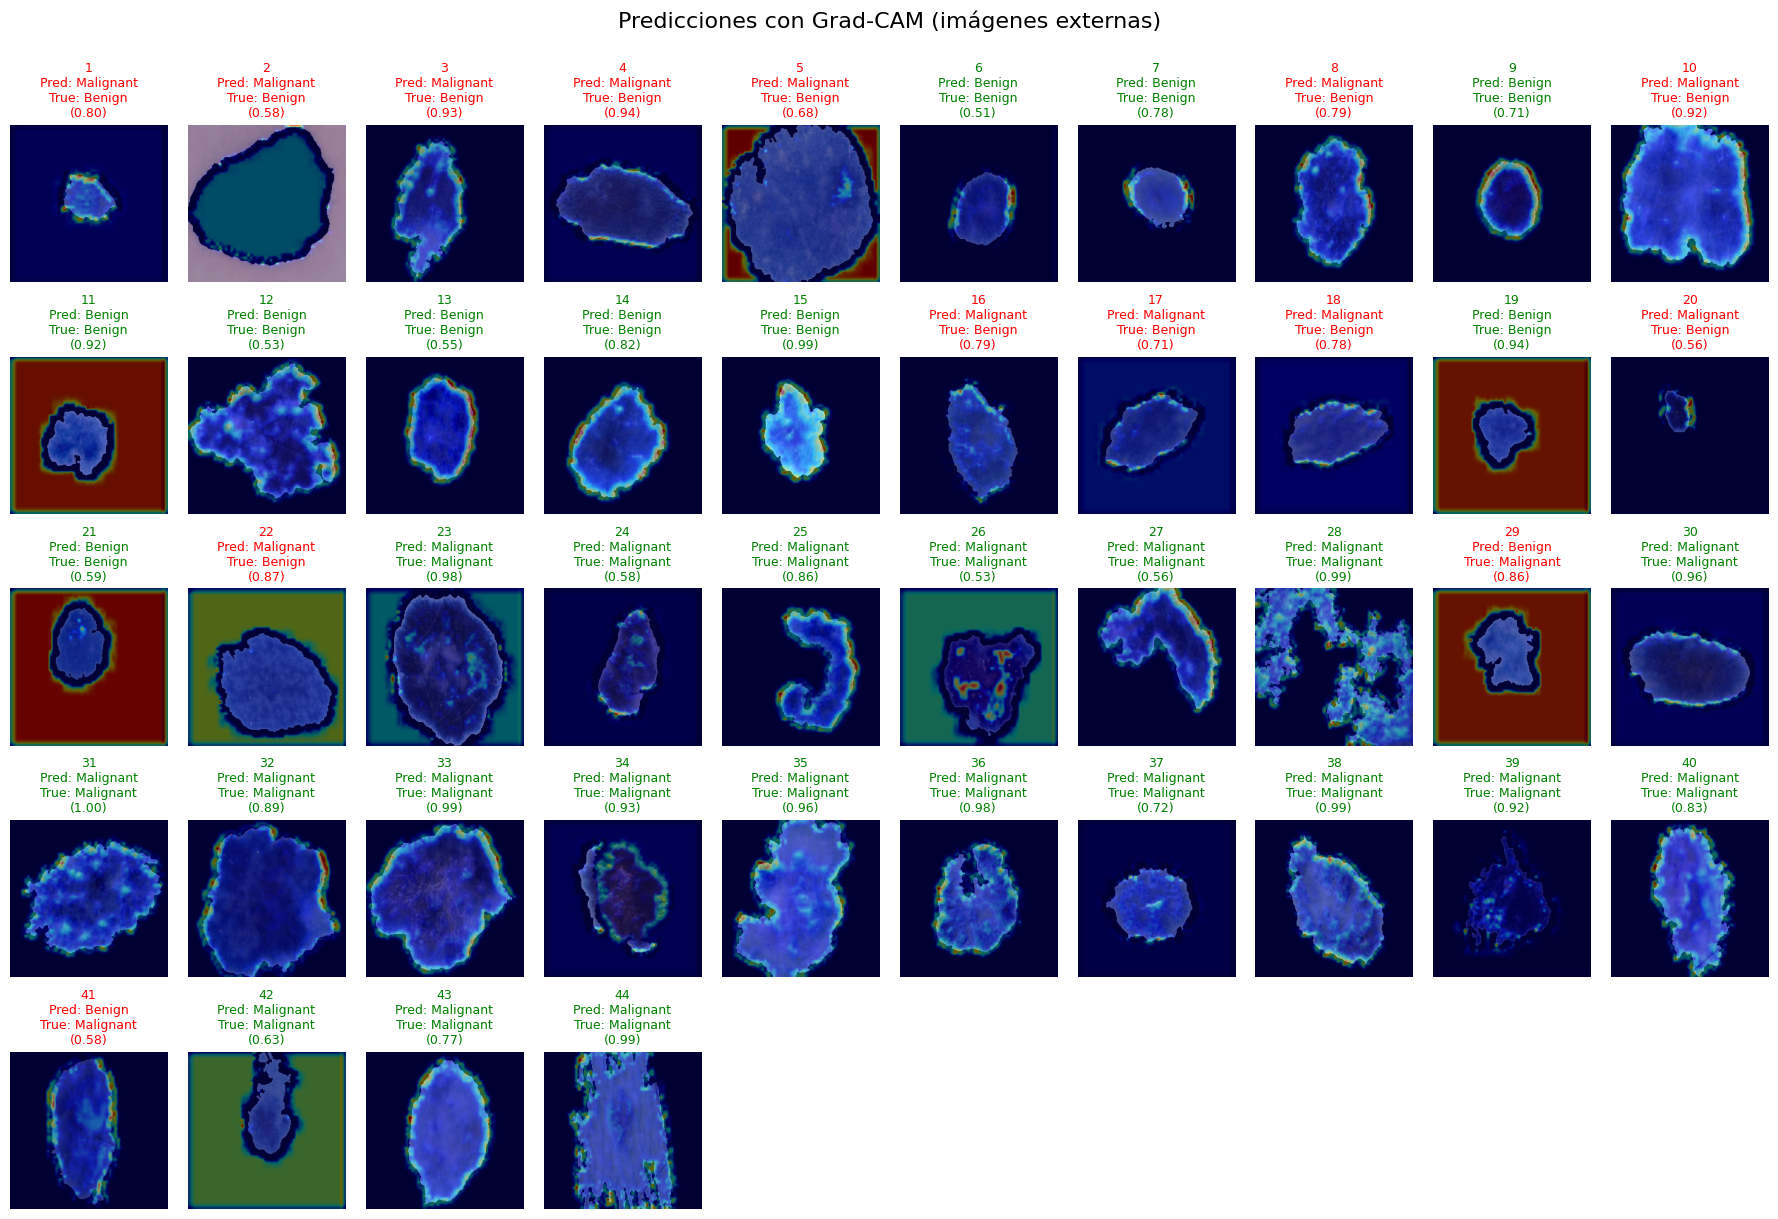

In [89]:
N = 44 # número de imágenes a mostrar
rows, cols = 5, 10
plt.figure(figsize=(18, 12))

# --- Bucle principal ---
for i in range(N):
    img, _ = ext_gen[i]
    img_sample = img[0]
    img_array = np.expand_dims(img_sample, axis=0)

    # Grad-CAM sobre la última capa convolucional
    heatmap = make_gradcam_heatmap(img_array, modelo1, "conv3")

    # Redimensionar y superponer
    heatmap = cv2.resize(heatmap, (ROWS, COLS))
    heatmap_color = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_color, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted((img_sample * 255).astype("uint8"), 0.6, heatmap_color, 0.4, 0)

    # --- Predicción y etiqueta ---
    true_label = labels[true_classes[i]]
    pred_label = labels[pred_classes[i]]
    prob = pred_probs[i][pred_classes[i]]

    # --- Mostrar resultado ---
    plt.subplot(rows, cols, i + 1)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    color = "green" if true_label == pred_label else "red"
    plt.title(f"{i+1}\nPred: {pred_label}\nTrue: {true_label}\n({prob:.2f})", color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout(pad=1.5)
plt.suptitle("Predicciones con Grad-CAM (imágenes externas)", fontsize=16, y=1.03)
plt.show()

In [78]:
modelo1.save("MelanomaNet.keras")

# Guardar en formato HDF5 (.h5)
modelo1.save("MelanomaNet.h5")